Model training completed.


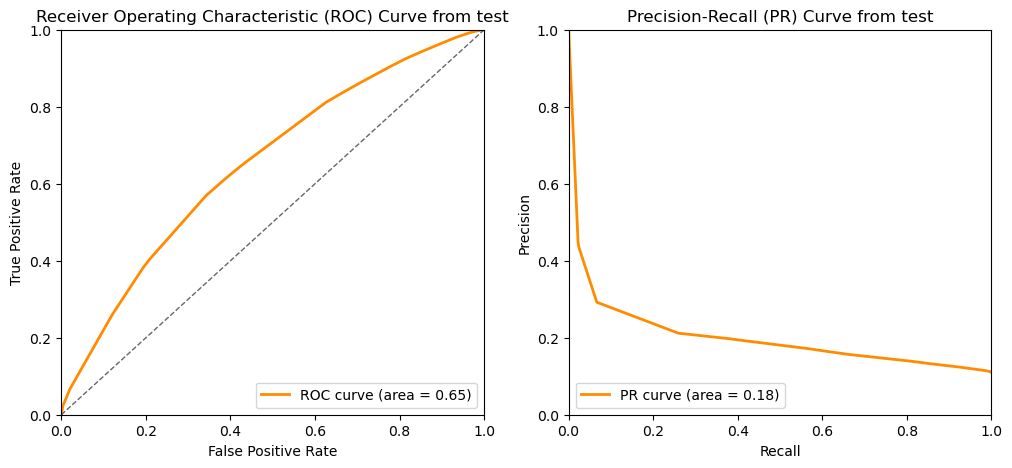

AUROC: 0.6518
AUPRC: 0.1798


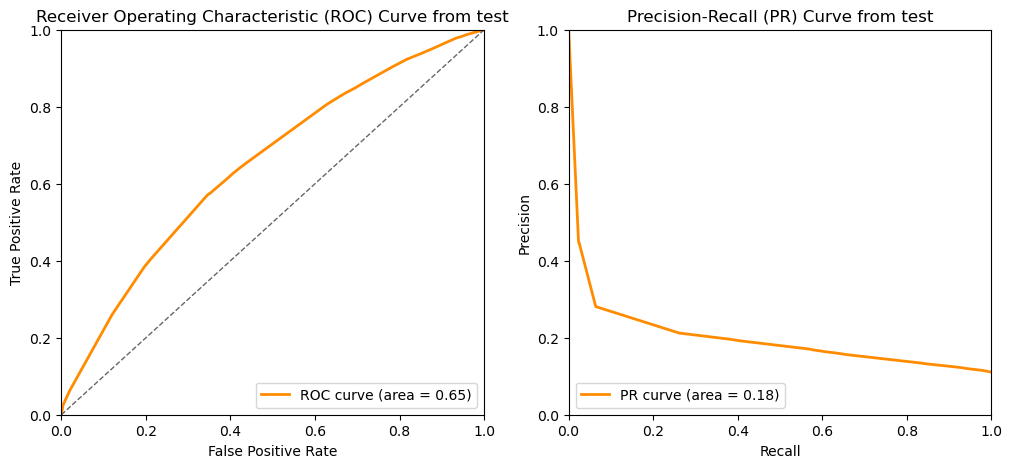

AUROC: 0.6484
AUPRC: 0.1787


[0.6484414236901583,
 0.6408089973892369,
 0.6572495535194646,
 0.645027182603134,
 0.5710743801652892,
 0.6542195284811751,
 0.17032289869361597,
 0.9246460980036297,
 0.2623884564268084]

In [5]:
from ehr_models import *
import ehr_utils
import pandas as pd
# drop mean bayesian
fill_method='bayesian'

file_path = f'data_cleaned/ver-noelectrolyte-logtransform_{fill_method}.csv'

X_train, X_test, Y_train, Y_test = ehr_utils.get_train_test(file_path, train_size=0.8, random_state=42)

## 需要测试哪个模型就取消注释对应的行,需要默认参数default=True，需要优化后的参数 默认=false
default = True
# model = init_adaBoost(default_parm=default)
model = init_decisionTree(default_parm=default)
# model = init_gaussianNB(default_parm=default)
# model = init_gradientBoosting(default_parm=default)
# model = init_lightGBM(default_parm=default)
# model = init_linearDiscriminantAnalysis(default_parm=default)
# model = init_logisticRegression(default_parm=default)
# model = init_MLPClassifier(default_parm=default)
# model = init_randomForest(default_parm=default)
# model = init_XGBoost(default_parm=default)

model.fit(X_train, Y_train)
print("Model training completed.")
Y_prob, Y_pred = ehr_utils.get_prediction_results(model, X_test)
Ytrain_prob, Ytrain_pred = ehr_utils.get_prediction_results(model, X_train)
ehr_utils.plot_roc_pr_curves(Y_train, Ytrain_prob, 'dt')
ehr_utils.plot_roc_pr_curves(Y_test, Y_prob, 'xgb')
ehr_utils.eval_model(Y_test, Y_prob, Y_pred)

In [6]:
import pickle
with open(f'trained_models_default/{fill_method}/DecisionTree_0.65.pkl', 'wb') as f:
    pickle.dump(model, f)